# OOP Hologram Optimization Workflow

This notebook is a runnable minimal workflow for the new OOP API. It uses a smaller demo grid by default so the CG optimization can run quickly. For the real SLM, replace `slm_shape` with the experimental grid, for example `(270, 480)` when using a 4x superpixel on a 1080 x 1920 SLM.


## 1. Imports

Run this cell first. The optimizer needs `numpy`, `scipy`, `torch`, and `matplotlib` in the active Python environment.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optical_planes import CameraPlane, SLMPlane
from propagator import Propagator
from optimizer import CGOptimizer
from initial_holograms import curvature_hologram
from loss_functions import build_circular_mask
from target_profiles import apply_psf_smoothing, build_rectangle_target


## 2. Physical and Numerical Parameters

The demo grid is intentionally small. The propagation plane is automatically padded by `padding_factor` inside `Propagator`.


In [9]:
# User inputs are native SLM values before padding.
full_slm_shape = (1080, 1920)
superpixel_size = 4
slm_shape = (
    full_slm_shape[0] // superpixel_size,
    full_slm_shape[1] // superpixel_size,
)

padding_factor = 2
camera_shape = (slm_shape[0] * padding_factor, slm_shape[1] * padding_factor)

wavelength_nm = 420.0
slm_pixel_pitch_um = 8.0
camera_pixel_pitch_um = 3.45
focal_length_mm = 200.0

# Beam diameters are physical 1/e^2 diameters on the native SLM plane.
beam_diameter_x_um = 5700.0
beam_diameter_y_um = 5900.0

rectangle_width_x_um = 300.0
rectangle_width_y_um = 100.0
psf_sigma_x_um = 10
psf_sigma_y_um = 10

# Initial hologram parameters for curvature_hologram().
initial_phase_linear_tilt = 0.0
initial_phase_astigmatism_weight = 0
initial_phase_quadratic_curvature = 3.6 * 1e-3
initial_phase_linear_angle_rad = np.pi / 4.0
initial_phase_conical_weight = 0.0

optimizer_maxiter = 200
loss_scale = 1e12
optimize_phase = True

# Optional slmsuite wavefront-calibration input beam.
use_slmsuite_input_beam = True
slmsuite_calibration_h5_path = "10806-SLM-wavefront_superpixel-calibration_00036.h5"
slmsuite_camera_shape = full_slm_shape
slmsuite_wavefront_r2_threshold = 0.5
slmsuite_remove_background = True
slmsuite_apply_calibration = True
slmsuite_amplitude_key = "amplitude"
slmsuite_phase_key = "phase"


## 3. Build the Input Beam

`SLMPlane.amplitude` and `SLMPlane.phase` represent the pure incoming beam. The hologram is stored separately.


Native SLM shape: (1080, 1920)
Superpixel SLM shape: (270, 480)
Full input beam shape: (1080, 1920)
Downsampled input beam shape: (270, 480)
Beam diameter on native SLM grid (px): 712.5 737.5
Beam diameter on superpixel grid (px): 178.125 184.375


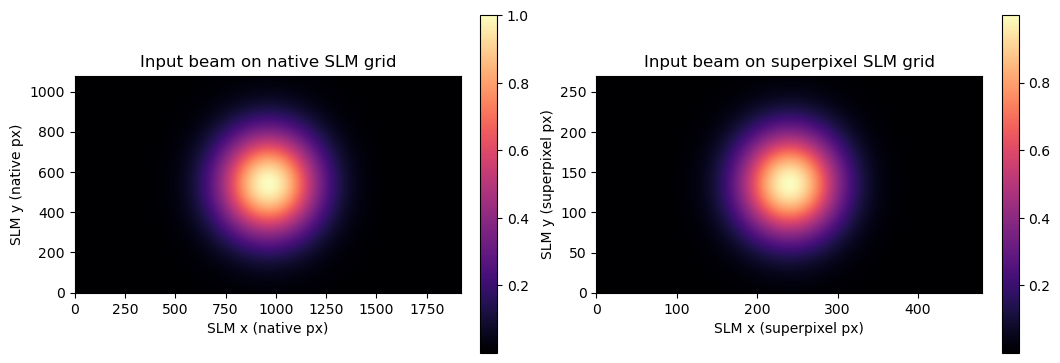

In [3]:
def downsample_by_superpixel(data, superpixel_size):
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError(f"data must be 2D, got shape {data.shape}.")
    if data.shape[0] % superpixel_size != 0 or data.shape[1] % superpixel_size != 0:
        raise ValueError(
            "data shape must be divisible by superpixel_size, "
            f"got data_shape={data.shape}, superpixel_size={superpixel_size}."
        )
    ny = data.shape[0] // superpixel_size
    nx = data.shape[1] // superpixel_size
    return data.reshape(ny, superpixel_size, nx, superpixel_size).mean(axis=(1, 3))

# Build the input beam on the native full SLM grid first.
x_full_px = np.arange(full_slm_shape[1], dtype=float) - full_slm_shape[1] / 2.0
y_full_px = np.arange(full_slm_shape[0], dtype=float) - full_slm_shape[0] / 2.0
x_full_grid_px, y_full_grid_px = np.meshgrid(x_full_px, y_full_px, indexing="xy")

beam_radius_x_full_px = (beam_diameter_x_um / slm_pixel_pitch_um) / 2.0
beam_radius_y_full_px = (beam_diameter_y_um / slm_pixel_pitch_um) / 2.0
input_beam_amplitude_full = np.exp(
    -((x_full_grid_px / beam_radius_x_full_px) ** 2 + (y_full_grid_px / beam_radius_y_full_px) ** 2)
)

# Downsample the native SLM beam to the superpixel compute grid.
input_beam_amplitude = downsample_by_superpixel(input_beam_amplitude_full, superpixel_size)
input_beam_phase = np.zeros(slm_shape, dtype=float)
initial_hologram = np.zeros(slm_shape, dtype=float)

print("Native SLM shape:", full_slm_shape)
print("Superpixel SLM shape:", slm_shape)
print("Full input beam shape:", input_beam_amplitude_full.shape)
print("Downsampled input beam shape:", input_beam_amplitude.shape)
print("Beam diameter on native SLM grid (px):", beam_diameter_x_um / slm_pixel_pitch_um, beam_diameter_y_um / slm_pixel_pitch_um)
print("Beam diameter on superpixel grid (px):", beam_diameter_x_um / (slm_pixel_pitch_um * superpixel_size), beam_diameter_y_um / (slm_pixel_pitch_um * superpixel_size))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
im0 = axes[0].imshow(input_beam_amplitude_full**2, origin="lower", cmap="magma", aspect="equal")
axes[0].set_title("Input beam on native SLM grid")
axes[0].set_xlabel("SLM x (native px)")
axes[0].set_ylabel("SLM y (native px)")
fig.colorbar(im0, ax=axes[0], shrink=0.82)

im1 = axes[1].imshow(
    input_beam_amplitude**2,
    origin="lower",
    cmap="magma",
    extent=(0, slm_shape[1], 0, slm_shape[0]),
    aspect="equal",
)
axes[1].set_title("Input beam on superpixel SLM grid")
axes[1].set_xlabel("SLM x (superpixel px)")
axes[1].set_ylabel("SLM y (superpixel px)")
fig.colorbar(im1, ax=axes[1], shrink=0.82)
plt.show()


## 3b. Optional: Load slmsuite Input Beam


/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/slmsuite/holography/algorithms/_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(
/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/slmsuite/hardware/cameras/camera.py:444: UserWarning: 'camera' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")
/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/slmsuite/hardware/cameraslms.py:456: UserWarning: You are using slmsuite 0.4.0, but the calibration in '10806-SLM-wavefront_superpixel-calibration_

Loaded slmsuite input beam shape: (270, 480)
Loaded slmsuite input phase shape: (270, 480)


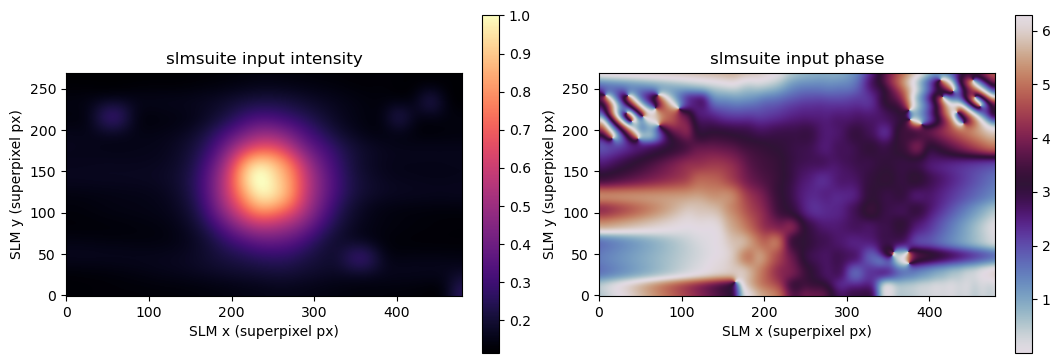

In [25]:
def downsample_phase_by_superpixel(phase, superpixel_size):
    phase_array = np.asarray(phase, dtype=float)
    if phase_array.ndim != 2:
        raise ValueError(f"phase must be 2D, got shape {phase_array.shape}.")
    real_part = downsample_by_superpixel(np.cos(phase_array), superpixel_size)
    imag_part = downsample_by_superpixel(np.sin(phase_array), superpixel_size)
    return np.angle(real_part + 1j * imag_part)


def _require_calibration_array(calibration_results, key, expected_shape):
    if key not in calibration_results:
        available_keys = sorted(str(item) for item in calibration_results.keys())
        raise KeyError(f"Calibration result key {key!r} was not found. Available keys: {available_keys}.")
    array = np.asarray(calibration_results[key], dtype=float)
    if array.shape != expected_shape:
        raise ValueError(f"Calibration result {key!r} shape must be {expected_shape}, got {array.shape}.")
    if not np.all(np.isfinite(array)):
        raise ValueError(f"Calibration result {key!r} contains NaN or infinite values.")
    return array


def load_slmsuite_input_beam_and_phase(
    calibration_h5_path,
    full_slm_shape,
    superpixel_size,
    slm_pixel_pitch_um,
    wavelength_nm,
    camera_shape,
    r2_threshold,
    remove_background,
    apply_calibration,
    amplitude_key,
    phase_key,
):
    from slmsuite.hardware.cameras.simulated import SimulatedCamera
    from slmsuite.hardware.cameraslms import FourierSLM
    from slmsuite.hardware.slms.simulated import SimulatedSLM

    slm_size_xy = (int(full_slm_shape[1]), int(full_slm_shape[0]))
    camera_size_xy = (int(camera_shape[1]), int(camera_shape[0]))
    slm = SimulatedSLM(slm_size_xy, pitch_um=(slm_pixel_pitch_um, slm_pixel_pitch_um), wav_um=wavelength_nm / 1000.0)
    camera = SimulatedCamera(slm, resolution=camera_size_xy)
    fourier_slm = FourierSLM(camera, slm)

    fourier_slm.load_calibration("wavefront_superpixel", file_path=calibration_h5_path)
    calibration_results = fourier_slm.wavefront_calibration_superpixel_process(
        plot=False,
        r2_threshold=r2_threshold,
        remove_background=remove_background,
        apply=apply_calibration,
    )
    amplitude_full = _require_calibration_array(calibration_results, amplitude_key, full_slm_shape)
    phase_full = _require_calibration_array(calibration_results, phase_key, full_slm_shape)
    amplitude = downsample_by_superpixel(np.clip(amplitude_full, 0.0, None), superpixel_size)
    phase = downsample_phase_by_superpixel(phase_full, superpixel_size)
    if np.max(amplitude) <= 0:
        raise ValueError("Loaded slmsuite amplitude contains no positive values after downsampling.")
    return amplitude / np.max(amplitude), np.mod(phase, 2.0 * np.pi), calibration_results


if use_slmsuite_input_beam:
    input_beam_amplitude, input_beam_phase, slmsuite_calibration_results = load_slmsuite_input_beam_and_phase(
        calibration_h5_path=slmsuite_calibration_h5_path,
        full_slm_shape=full_slm_shape,
        superpixel_size=superpixel_size,
        slm_pixel_pitch_um=slm_pixel_pitch_um,
        wavelength_nm=wavelength_nm,
        camera_shape=slmsuite_camera_shape,
        r2_threshold=slmsuite_wavefront_r2_threshold,
        remove_background=slmsuite_remove_background,
        apply_calibration=slmsuite_apply_calibration,
        amplitude_key=slmsuite_amplitude_key,
        phase_key=slmsuite_phase_key,
    )
    print("Loaded slmsuite input beam shape:", input_beam_amplitude.shape)
    print("Loaded slmsuite input phase shape:", input_beam_phase.shape)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
    im0 = axes[0].imshow(input_beam_amplitude**2, origin="lower", cmap="magma", aspect="equal")
    axes[0].set_title("slmsuite input intensity")
    axes[0].set_xlabel("SLM x (superpixel px)")
    axes[0].set_ylabel("SLM y (superpixel px)")
    fig.colorbar(im0, ax=axes[0], shrink=0.82)

    im1 = axes[1].imshow(input_beam_phase, origin="lower", cmap="twilight", aspect="equal")
    axes[1].set_title("slmsuite input phase")
    axes[1].set_xlabel("SLM x (superpixel px)")
    axes[1].set_ylabel("SLM y (superpixel px)")
    fig.colorbar(im1, ax=axes[1], shrink=0.82)
    plt.show()
else:
    slmsuite_calibration_results = None
    print("Using analytic Gaussian input beam. Set use_slmsuite_input_beam=True to load slmsuite calibration data.")


## 4. Create Optical Planes

The `CameraPlane.scale_um` value is only a placeholder here. `Propagator` overwrites it using `delta = wavelength * focal_length / SLM_size`.


In [4]:
slm = SLMPlane(
    shape=slm_shape,
    wavelength_nm=wavelength_nm,
    pixel_pitch_um=slm_pixel_pitch_um,
    superpixel_size=superpixel_size,
    amplitude=input_beam_amplitude,
    phase=input_beam_phase,
    hologram=initial_hologram,
)

camera = CameraPlane(
    shape=camera_shape,
    wavelength_nm=wavelength_nm,
    scale_um=(1.0, 1.0),
    camera_pixel_pitch_um=camera_pixel_pitch_um,
    amplitude=np.zeros(camera_shape, dtype=float),
    phase=np.zeros(camera_shape, dtype=float),
)

print("SLM shape:", slm.shape)
print("Camera shape:", camera.shape)
print("SLM scale um:", slm.scale_um)


SLM shape: (270, 480)
Camera shape: (540, 960)
SLM scale um: (32.0, 32.0)


## 5. Create Propagator and Test Propagation

`Propagator.propagate("sft")` updates `padding_farfield` and `camera_plane` in place.


Padding far-field shape: (540, 960)
Padding far-field unit type: xy
Focal-plane scale um: (9.722222222222221, 5.46875)


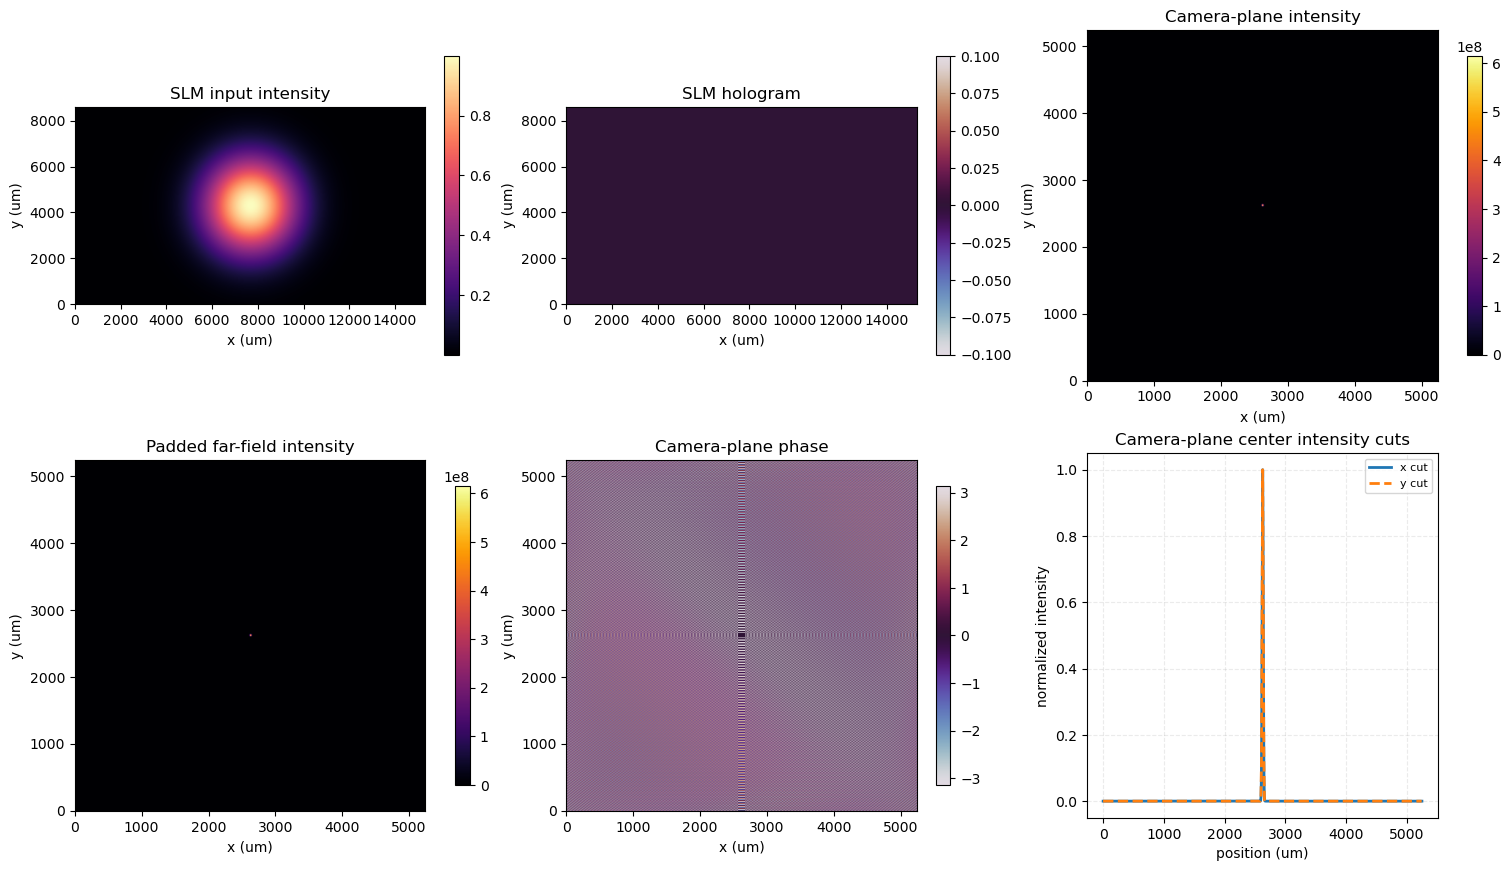

In [5]:
propagator = Propagator(
    slm_plane=slm,
    camera_plane=camera,
    focal_length_mm=focal_length_mm,
    padding_factor=padding_factor,
)

propagator.propagate("sft")

print("Padding far-field shape:", propagator.padding_farfield.shape)
print("Padding far-field unit type:", propagator.padding_farfield.unit_type)
print("Focal-plane scale um:", propagator.camera_plane.scale_um)

propagator.plot_propagation_summary(profile_mask=None)
plt.show()


## 6. Create Optimizer and Target

The target size is specified in focal-plane physical units.


Target plane shape: (540, 960)
Circular mask center (um): (2622.265625, 2620.1388888888887)
Circular mask radius (um): 250.0
Target mask active pixels: 3700
Initial hologram shape: (270, 480)


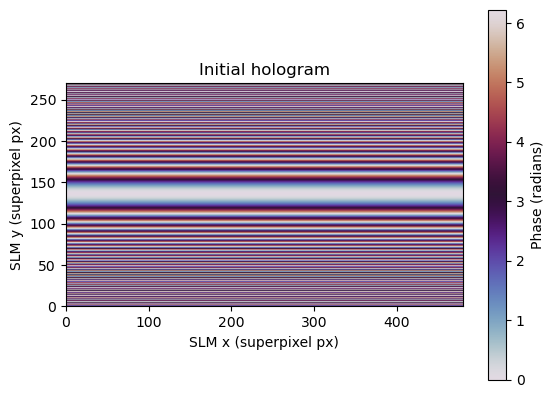

In [6]:
target_ideal_amplitude = build_rectangle_target(
    shape=propagator.camera_plane.shape,
    x_axis_um=propagator.camera_plane.x_axis_um,
    y_axis_um=propagator.camera_plane.y_axis_um,
    width_x_um=rectangle_width_x_um,
    width_y_um=rectangle_width_y_um,
)
target_amplitude = apply_psf_smoothing(
    target=target_ideal_amplitude,
    sigma_x_um=0.0 if psf_sigma_x_um is None else psf_sigma_x_um,
    sigma_y_um=0.0 if psf_sigma_y_um is None else psf_sigma_y_um,
    scale_um=propagator.camera_plane.scale_um,
)
target_phase = np.zeros_like(target_amplitude)

mask_center_x_um = 0.5 * (propagator.camera_plane.x_axis_um[0] + propagator.camera_plane.x_axis_um[-1])
mask_center_y_um = 0.5 * (propagator.camera_plane.y_axis_um[0] + propagator.camera_plane.y_axis_um[-1])
mask_radius_um = max(rectangle_width_x_um, rectangle_width_y_um) / 2.0 + 100.0
target_mask = build_circular_mask(
    shape=propagator.camera_plane.shape,
    x_axis_um=propagator.camera_plane.x_axis_um,
    y_axis_um=propagator.camera_plane.y_axis_um,
    center_x_um=mask_center_x_um,
    center_y_um=mask_center_y_um,
    radius_um=mask_radius_um,
)

target_plane = CameraPlane(
    shape=propagator.camera_plane.shape,
    wavelength_nm=wavelength_nm,
    scale_um=propagator.camera_plane.scale_um,
    camera_pixel_pitch_um=camera_pixel_pitch_um,
    amplitude=target_amplitude,
    phase=target_phase,
)

optimizer = CGOptimizer(
    propagator=propagator,
    target_plane=target_plane,
    target_mask=target_mask,
)
initial_hologram = curvature_hologram(
    shape=propagator.slm_plane.shape,
    linear_tilt=initial_phase_linear_tilt,
    astigmatism_weight=initial_phase_astigmatism_weight,
    quadratic_curvature=initial_phase_quadratic_curvature,
    linear_angle_rad=initial_phase_linear_angle_rad,
    conical_weight=initial_phase_conical_weight,
    center=(propagator.slm_plane.shape[0] / 2.0, propagator.slm_plane.shape[1] / 2.0),
)
optimizer.set_initial_hologram_array(initial_hologram)

print("Target plane shape:", optimizer.target_plane.shape)
print("Circular mask center (um):", (float(mask_center_x_um), float(mask_center_y_um)))
print("Circular mask radius (um):", float(mask_radius_um))
print("Target mask active pixels:", int(np.sum(target_mask > 0)))
print("Initial hologram shape:", optimizer.initial_hologram.shape)

plt.imshow(initial_hologram, origin="lower", cmap="twilight", extent=(0, slm_shape[1], 0, slm_shape[0]), aspect="equal")
plt.title("Initial hologram")
plt.xlabel("SLM x (superpixel px)")
plt.ylabel("SLM y (superpixel px)")
plt.colorbar(label="Phase (radians)")
plt.show()


## 7. Run CG Optimization

For a first check, keep `optimizer_maxiter` small. Increase it after the workflow is verified.


In [10]:
optimizer.optimize(
    maxiter=optimizer_maxiter,
    loss_scale=loss_scale,
    optimize_phase=optimize_phase,
)

print("Optimization finished")
print("Evaluations:", len(optimizer.loss_history))
print("Iterations:", len(optimizer.iteration_loss_history))
print("Time (s):", optimizer.optimization_time_sec)


Optimization finished
Evaluations: 299
Iterations: 200
Time (s): 212.11941629182547


## 8. Inspect Results

`get_full_resolution_hologram()` expands the optimized superpixel hologram back to the original SLM pixel grid.


Efficiency: 0.1027113388728544
Fidelity: 0.9994441702181222
RMS error: 0.08811018296327874
Phase error: 1.7172699469105723
Final hologram shape: (270, 480)
Full-resolution hologram shape: (1080, 1920)


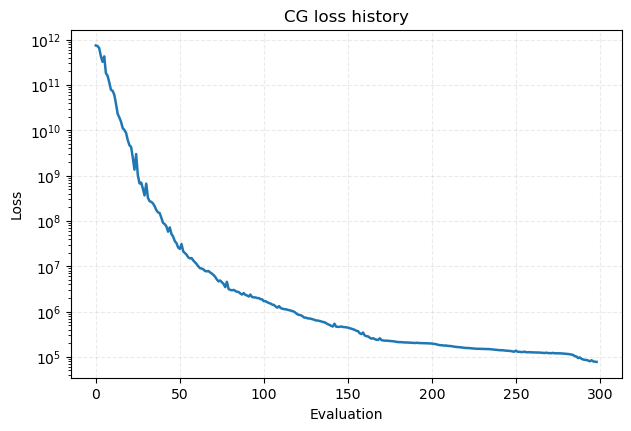

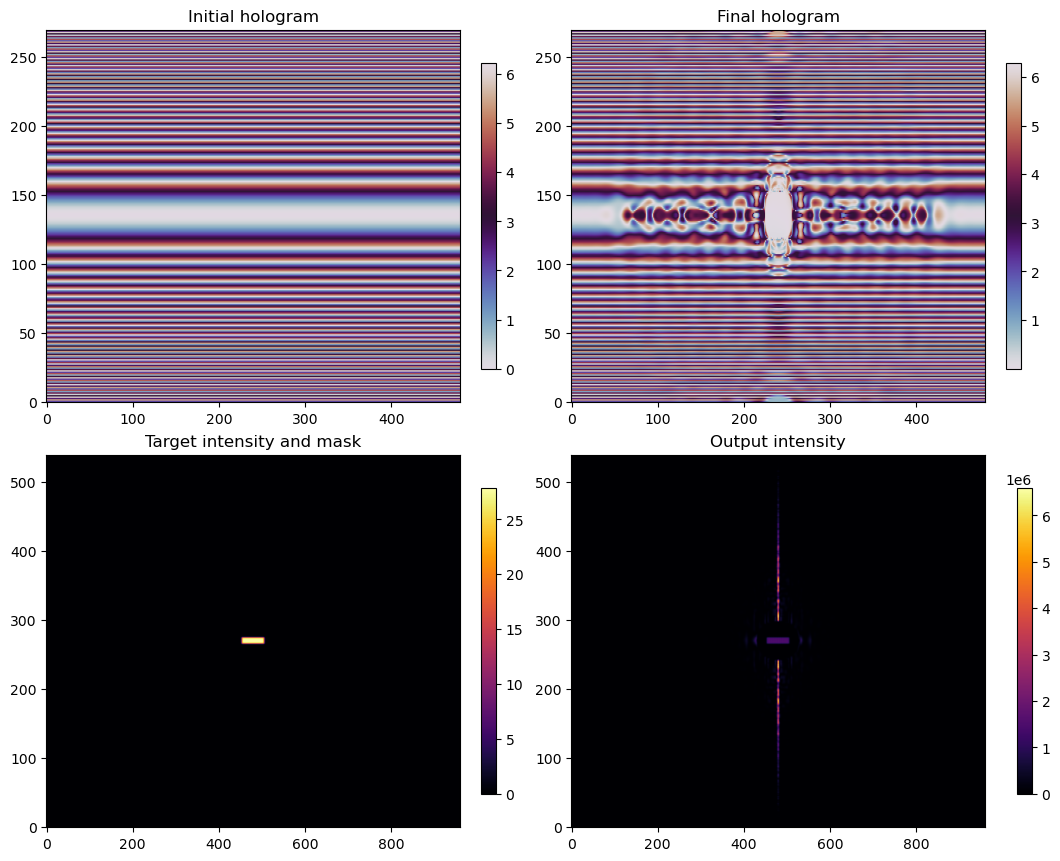

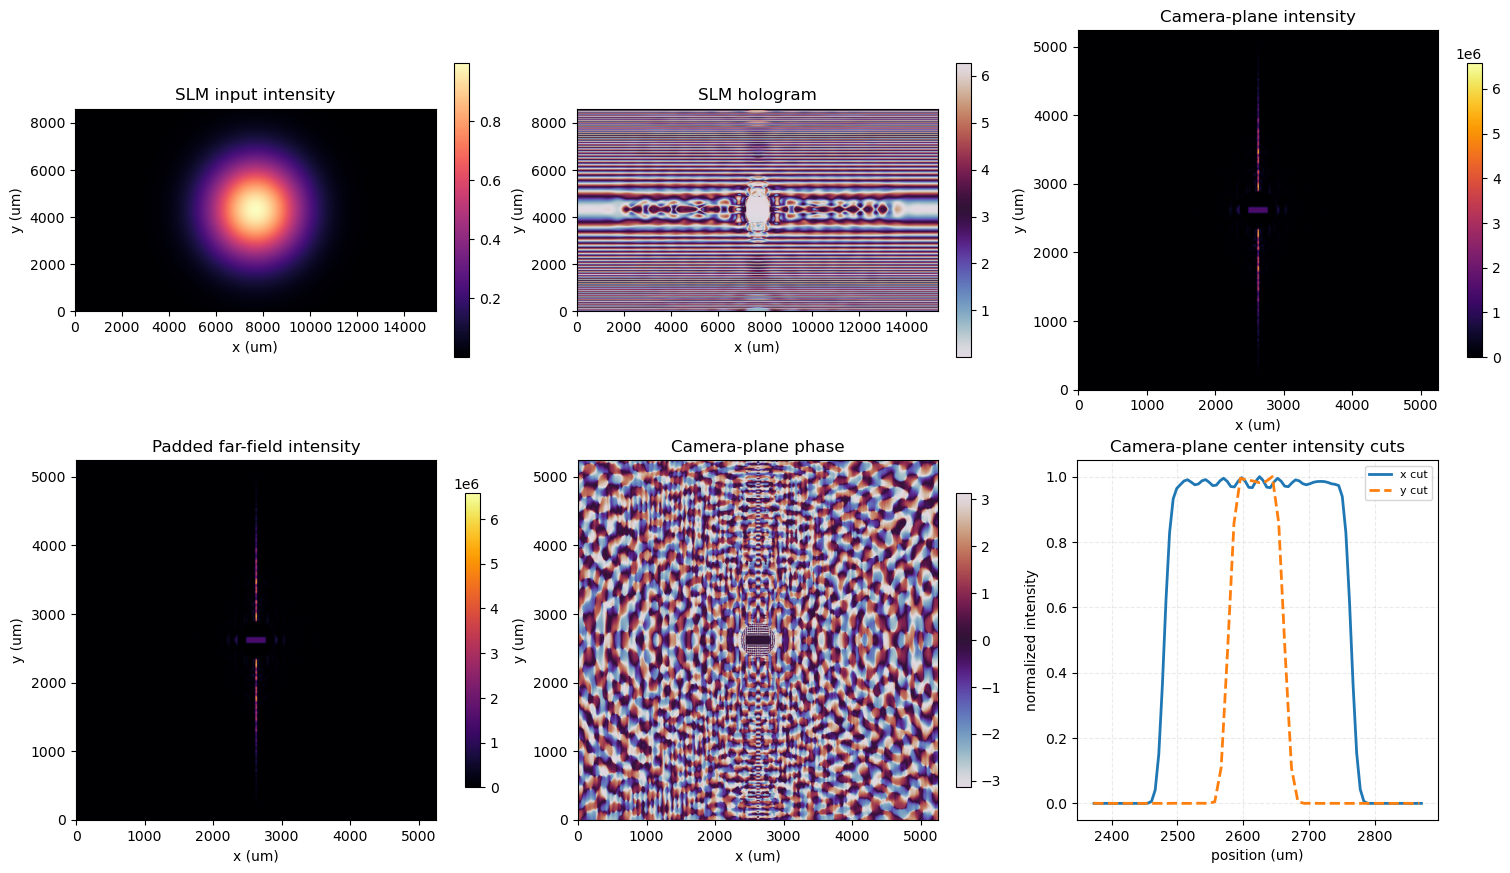

In [11]:
result = optimizer.get_result_summary()
final_hologram = optimizer.get_final_hologram()
full_resolution_hologram = optimizer.get_full_resolution_hologram()

print("Efficiency:", result.efficiency)
print("Fidelity:", result.fidelity)
print("RMS error:", result.rms_error)
print("Phase error:", result.phase_error)
print("Final hologram shape:", final_hologram.shape)
print("Full-resolution hologram shape:", full_resolution_hologram.shape)

optimizer.plot_loss_history()
plt.show()

optimizer.plot_result_summary()
plt.show()

optimizer.propagator.plot_propagation_summary(profile_mask=result.target_mask)
plt.show()


## 9. Optional: Save the Hologram

Uncomment this cell when you want to save the generated hologram for physical SLM use.


In [ ]:
# np.save("oop_final_hologram_superpixel.npy", final_hologram)
# np.save("oop_final_hologram_full_resolution.npy", full_resolution_hologram)
